# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

    Выполнила: Тулянцева Альбина
    Дата: 01.04.2026

    Описание: на рынке доставки кофе высокая конкуренция, поэтому привлечение нового клиента обходится в 5–7 раз дороже, чем удержание существующего. В последние месяцы Happy Beans Coffee столкнулись с проблемой: каждый месяц сервис теряет 10% клиентской базы, что напрямую снижает ежемесячную выручку. Из-за этого также неэффективно расходуется маркетинговый 
    бюджет: он «работает вхолостую», не обеспечивая прироста клиентской базы.
    Для исправления ситуации глава стартапа Савелий инициировал проект по прогнозированию оттока клиентов, над которым
    предстоит работать.

    Цель: построить модель бинарной классификации, которая спрогнозирует вероятность оттока каждого клиента в следующем 
    месяце.

    Данные:

    user_id — идентификатор пользователя.
    days_since_last_order — количество дней, прошедших с последнего заказа.
    order_frequency_month — среднее число заказов в месяц.
    order_frequency_week — среднее число заказов в неделю.
    avg_order_value — средний чек, в рублях.
    median_order_value — медианный чек, в рублях.
    total_spent_last_month — сумма заказов за последний месяц.
    total_spent_last_week — сумма заказов за последнюю неделю.
    discount_usage_rate — доля заказов со скидкой за последний месяц.
    last_coffee_type — сорт кофе, купленный пользователем в последний раз на момент сбора данных.
    preferred_roast — предпочитаемый тип обжарки.
    milk_preference — предпочитаемый тип молока.
    seasonal_menu_tried — отметка о том, пробовал ли пользователь новейшее сезонное меню.
    coffee_bean_origin — страна происхождения зерна.
    last_drink_size — размер последнего заказа, совершённого на момент сбора данных.
    subscription_status — тип подписки пользователя.
    app_opens_per_week — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.
    notifications_enabled — включены ли у пользователя уведомления.
    review_rating_last_10 — средняя оценка последних на момент сбора данных десяти заказов клиента.
    review_rating_last_1 — оценка последнего на момент сбора данных заказа клиента.
    app_crashes_last_month — сколько раз приложение зависало за последний месяц.
    seasons — текущее время года.
    days_since_last_promo — сколько дней прошло с последнего использования акции или промокода.
    phone_type — тип устройства, с которого пользователь чаще всего совершал покупки.
    coffee_preference_change — менялись ли вкусовые предпочтения пользователя.
    geo_id — идентификатор региона пользователя.
    churn — перестал ли пользователь пользоваться сервисом.
    
    План выполнения:
    1.Подготовка среды и библиотек.
    2.Исследовательский анализ данных (EDA).
    3.Предобработка данных.
    4.Обучение и оценка базовой модели.
    5.Создание и отбор новых признаков.
    6.Подбор гиперпараметров модели.
    7.Финальное обучение модели и подготовка артефактов.
    
    Выбор метрики: бизнесу важно найти как можно больше клиентов, собирающихся уйти(Recall), а также максимально точно определить собирающихся перестать пользоваться продуктом пользователей(Precision). Так как данные несбалансированы, т.е. намного больше клиентов остаются, чем уходят, в качестве основной метрики подойдет PR AUC.

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
!pip install -U scikit-learn -q
#Импорт основных библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#Импорт scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, average_precision_score, roc_auc_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier

#Импорт phik
!pip install phik -q
from phik import phik_matrix

#Импорт joblib
import joblib
from datetime import datetime

#Фиксируем random_state
RANDOM_STATE = 42

In [2]:
#Загрузка данных
df = pd.read_csv('coffee_churn_dataset.csv', sep=',',decimal='.')

## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

**2.1 Краткое описание данных**

In [3]:
df.head()

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [5]:
df.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


В данных присутствует большое количество пропусков. Полный набор данных имеют только столбцы "user_id" и "churn". 
Также в данных имеется большой разброс, что говорит о разном поведении пользователей. В столбцах, связанных с прибылью, присутствуют отрицательные значения. Такие значения могут быть ошибочными, поэтому в дальнейшем их нужно будет удалить. Во многих данных есть выбросы, поэтому далее их надо исследовать.

**2.2 Анализ целевой переменной**

In [6]:
#Считаем ушедших гостей
num_leaved = df['churn'].sum()
#Оставшиеся
num_stayed =  df['churn'].count() - num_leaved
#Доля
leaved_ratio = round((num_leaved/df['churn'].count())*100, 2)

print(f'Количество ушедших пользователей: {num_leaved}')
print(f'Количество оставшихся пользователей: {num_stayed}')
print(f'Доля ушедших пользователей: {leaved_ratio}%')

Количество ушедших пользователей: 629
Количество оставшихся пользователей: 9821
Доля ушедших пользователей: 6.02%


Здесь можно увидеть, что даные не сбалансированы. Лишь 629(6%) покидают бизнес. Большинство всё же остаются, поэтому важно научить модель, которая уметь находить меньшинство.

**2.3 Проверка на явные дубликаты**

In [7]:
#Считаем дубликаты
len_duplicates = df.duplicated().sum()

print(f'Количество дубликатов:{len_duplicates}')

Количество дубликатов:0


In [8]:
len_duplicates_id_location = df.duplicated(subset=['user_id', 'geo_location']).sum()

print(f'Количество дубликатов в связке user_id, geo_location:{len_duplicates_id_location}')

Количество дубликатов в связке user_id, geo_location:0


**2.4 Признаки**

Для правильной работы модели нужно избавиться от признаков, не связанных с целевой переменной или вызывающих ложную корреляцию. В первую очередь нужно удалить "user_id", так как id клиента не имеет отношения к его лояльности. Также удалим "preferred_roast" и "milk_preferrence", так как личные предпочтения клиента не влияют на переменную, если доставка может предложить все виды обжарки и молока, и если удаляются признаки предпочтения, то удаляем "coffee_preference_change". Удалить также стоит столбец "coffee_bean_origin", так как производство зерна чаще всего не влияет на отток клиентов. Еще удалим "last_coffee_type" и "last_drink_size", так как последний заказ может не отражать поведение пользователя во время всех пользований услугами компании. Также удалим "phone_type", так как тип устройства, с которого был совершен заказ, не влияет на качество сервиса и продукции компании.

In [9]:
columns_to_drop = ['user_id', 'preferred_roast', 'milk_preference', 'coffee_preference_change',
                   'last_coffee_type', 'last_drink_size', 'phone_type', 'coffee_bean_origin']

old_df = df.shape
#Удаляем колонки
df = df.drop(columns=columns_to_drop)

new_df = df.shape

print(f'Размер датасета до удаления столбцов:{old_df}')
print(f'Размер датасета после удаления столбцов:{new_df}')

Размер датасета до удаления столбцов:(10450, 27)
Размер датасета после удаления столбцов:(10450, 19)


**2.5 Пропущенные значения**

In [10]:
#Считаем пропуски
missed_values = df.isna().sum()

print(missed_values)

days_since_last_order     945
order_frequency_month     600
order_frequency_week      388
avg_order_value           583
median_order_value        831
total_spent_last_month    294
total_spent_last_week     944
discount_usage_rate       397
seasonal_menu_tried       989
subscription_status       938
app_opens_per_week        896
notifications_enabled     537
review_rating_last_10     693
review_rating_last_1      857
app_crashes_last_month    721
seasons                   679
days_since_last_promo     731
geo_location              110
churn                       0
dtype: int64


In [11]:
#Изучим доли пропусков в бинарных признаках
for column in ['seasonal_menu_tried', 'notifications_enabled']:
    missing_ratio = round((df[column].isna().sum()/len(df))*100, 2)
    print(f'Доля пропущенных значений в столбце {column}: {missing_ratio}%')    

Доля пропущенных значений в столбце seasonal_menu_tried: 9.46%
Доля пропущенных значений в столбце notifications_enabled: 5.14%


In [12]:
#Изучим распределение данных в столбце 'seasonal_menu_tried'
menu_tried = df['seasonal_menu_tried'].sum()
menu_not_tried = len(df) - menu_tried
menu_tried_ratio = round((menu_tried/len(df))*100,2)

print(f'Количество гостей, попробовавших меню: {menu_tried}')
print(f'Количество гостей, не попробовавших меню: {menu_not_tried}')
print(f'Доля гостей, попробовавших меню: {menu_tried_ratio}%')

Количество гостей, попробовавших меню: 6634.0
Количество гостей, не попробовавших меню: 3816.0
Доля гостей, попробовавших меню: 63.48%


В столбце "seasonal_menue_tried" наблюдается почти 10% пропусков, что достаточно много, ведь данные распределены сбалансировано, и будет некорректно заменять пропущенные значения модой. Поэтому пропущенные строки в этом столбце лучше удалить.
В столбце "notifications_enabled" небольшой процент пропусков, поэтому там заменим значения на моду. В остальных столбцах датасета заменим значения на медиану после деления на выборки.

In [13]:
old_df = len(df)
#Удаляем строки
df = df.dropna(subset=['seasonal_menu_tried'])

new_df = len(df)
deleted_rows = old_df - new_df

print(f'Количество удаленных строк:{deleted_rows}')
print(f'Доля удаленных строк:{round(deleted_rows/old_df, 4)}')

Количество удаленных строк:989
Доля удаленных строк:0.0946


**2.6 Анализ категориальных признаков**

В данных наблюдается 3 категориальных признаков с типом object. Эти признаки: "subscription_status", "seasons", "geo_location". Проверим эти столбцы на наличие неявных дубликатов

In [14]:
for column in ['subscription_status', 'seasons', 'geo_location']:
    print(f'\nУникальные значения в столбце {column}: {df[column].unique()}')


Уникальные значения в столбце subscription_status: <StringArray>
['none', 'premium', 'basic', nan, 'pro']
Length: 5, dtype: str

Уникальные значения в столбце seasons: <StringArray>
['autumn', 'spring', 'summer', 'winter', nan]
Length: 5, dtype: str

Уникальные значения в столбце geo_location: <StringArray>
['geo_95', 'geo_25',  'geo_2', 'geo_19', 'geo_68',  'geo_3', 'geo_45',
 'geo_15',      nan, 'geo_30',
 ...
 'geo_89', 'geo_36', 'geo_80',  'geo_6', 'geo_47', 'geo_77', 'geo_37',
 'geo_44', 'geo_79',  'geo_7']
Length: 101, dtype: str


In [15]:
#Посмотрим на распределение данных в geo_location
print(df['geo_location'].value_counts())

geo_location
geo_2     1465
geo_3     1428
geo_1     1396
geo_99     106
geo_95     101
          ... 
geo_41      37
geo_38      37
geo_45      35
geo_86      35
geo_60      35
Name: count, Length: 100, dtype: int64


По распределению видно, что данные не равномерные. В первых трех регионах находится в разы больше людей, чем в остальных. Это может мешать работе модели и создает риск ее переобучения. Для поддержания качества модели, удалим этот признак.

In [16]:
df = df.drop(columns=['geo_location'])

В данных не были обнаружены неявные дубликаты. В дальнейшем при построении пайплайна оставшиеся признаки нужно будет кодировать, чтобы модель смогла найти взаимосвязь с целевой переменной. Для признаков будем использовать One-Hot Encoding, так как значений признаков мало.

**2.7 Возможные взаимосвязи переменных**

Для обучения улучшенной модели можно будет умножить "discount_usage_rate" на "order_frequency_month", чтобы модель смогла увидеть абсолютное количество заказов со скидкой. Также можно вычислить логарифм из признаков с прибылью. Еще можно поделить total_spent на order_frequency, чтобы увидеть среднюю стоимость заказа.

**2.8 Анализ выбросов**

In [17]:
#Создаем словарь обозначений
plot_labels = {
    'days_since_last_order': {
        'title': 'Распределение дней с последнего заказа',
        'xlabel': 'Дней с последнего заказа (дни)',
        'ylabel': 'Количество пользователей'
    },
    'order_frequency_month': {
        'title': 'Распределение частоты заказов в месяц',
        'xlabel': 'Заказов в месяц',
        'ylabel': 'Количество пользователей'
    },
    'order_frequency_week': {
        'title': 'Распределение частоты заказов в неделю',
        'xlabel': 'Заказов в неделю',
        'ylabel': 'Количество пользователей'
    },
    'avg_order_value': {
        'title': 'Распределение среднего чека',
        'xlabel': 'Средний чек (руб.)',
        'ylabel': 'Количество пользователей'
    },
    'median_order_value': {
        'title': 'Распределение медианного чека',
        'xlabel': 'Медианный чек (руб.)',
        'ylabel': 'Количество пользователей'
    },
    'total_spent_last_month': {
        'title': 'Распределение суммы заказов за последний месяц',
        'xlabel': 'Сумма заказов (руб.)',
        'ylabel': 'Количество пользователей'
    },
    'total_spent_last_week': {
        'title': 'Распределение суммы заказов за последнюю неделю',
        'xlabel': 'Сумма заказов (руб.)',
        'ylabel': 'Количество пользователей'
    },
    'discount_usage_rate': {
        'title': 'Распределение доли заказов со скидкой',
        'xlabel': 'Доля заказов со скидкой',
        'ylabel': 'Количество пользователей'
    },
    'app_opens_per_week': {
        'title': 'Распределение частоты открытий приложения в неделю',
        'xlabel': 'Открытий приложения в неделю',
        'ylabel': 'Количество пользователей'
    },
    'notifications_enabled': {
        'title': 'Распределение включенных уведомлений',
        'xlabel': 'Уведомления включены (0=Нет, 1=Да)',
        'ylabel': 'Количество пользователей'
    },
    'review_rating_last_10': {
        'title': 'Распределение среднего рейтинга за последние 10 заказов',
        'xlabel': 'Средний рейтинг',
        'ylabel': 'Количество пользователей'
    },
    'review_rating_last_1': {
        'title': 'Распределение рейтинга последнего заказа',
        'xlabel': 'Рейтинг последнего заказа',
        'ylabel': 'Количество пользователей'
    },
    'app_crashes_last_month': {
        'title': 'Распределение количества зависаний приложения за месяц',
        'xlabel': 'Количество зависаний',
        'ylabel': 'Количество пользователей'
    },
    'days_since_last_promo': {
        'title': 'Распределение дней с последнего использования промо',
        'xlabel': 'Дней с последнего промо',
        'ylabel': 'Количество пользователей'
    },
    'seasonal_menu_tried': {
        'title': 'Распределение клиентов, пробовавших сезонное меню',
        'xlabel': 'Меню пробовали (0=Нет, 1=Да)',
        'ylabel': 'Количество пользователей'
    }
}

In [18]:
#Непрерывные признаки
continuous_cols = [
    col for col in df.columns
    if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > 10
]

#Дискретные признаки
discrete_cols = [
    col for col in df.columns
    if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() <= 10
]

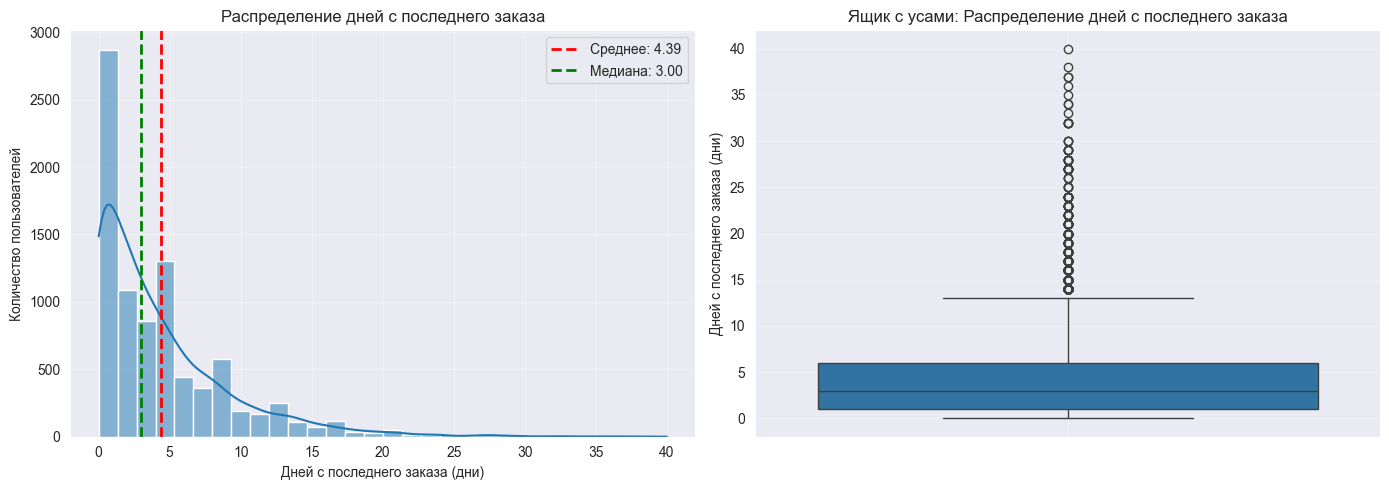

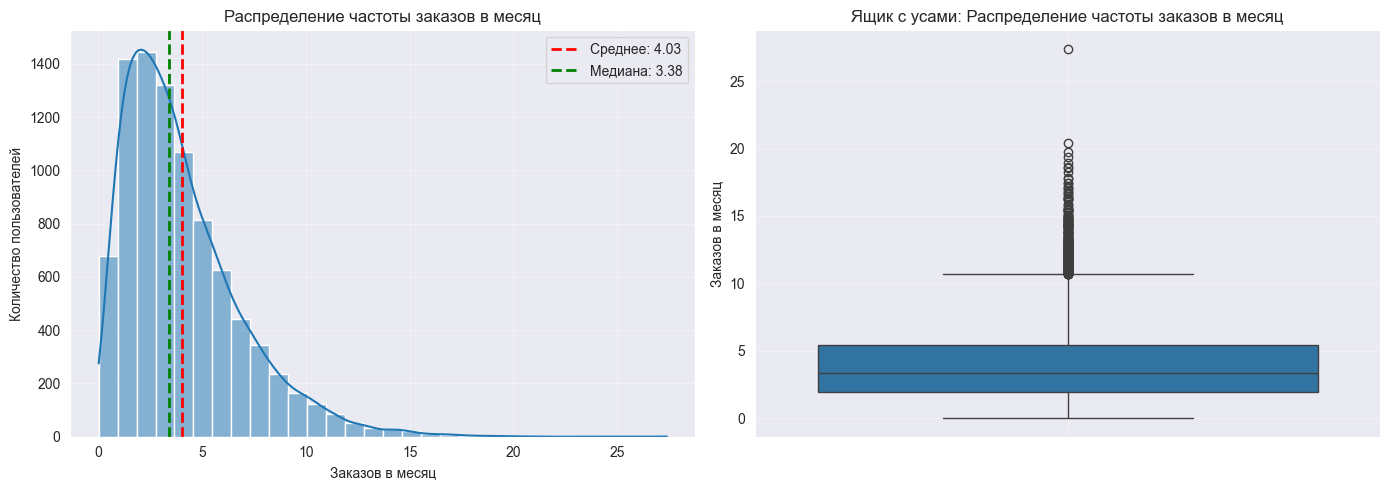

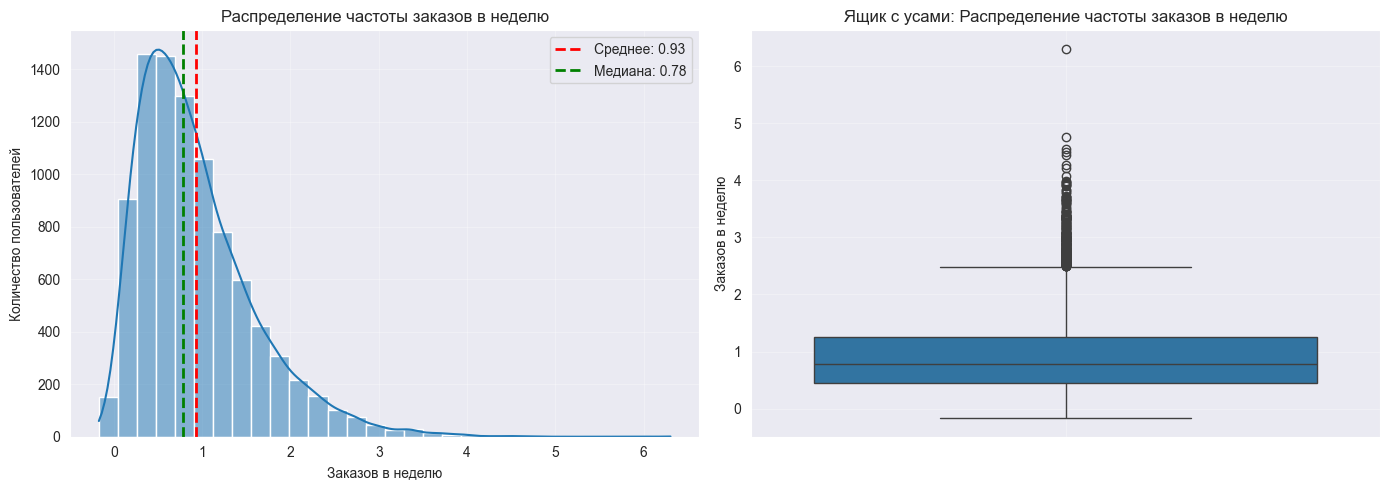

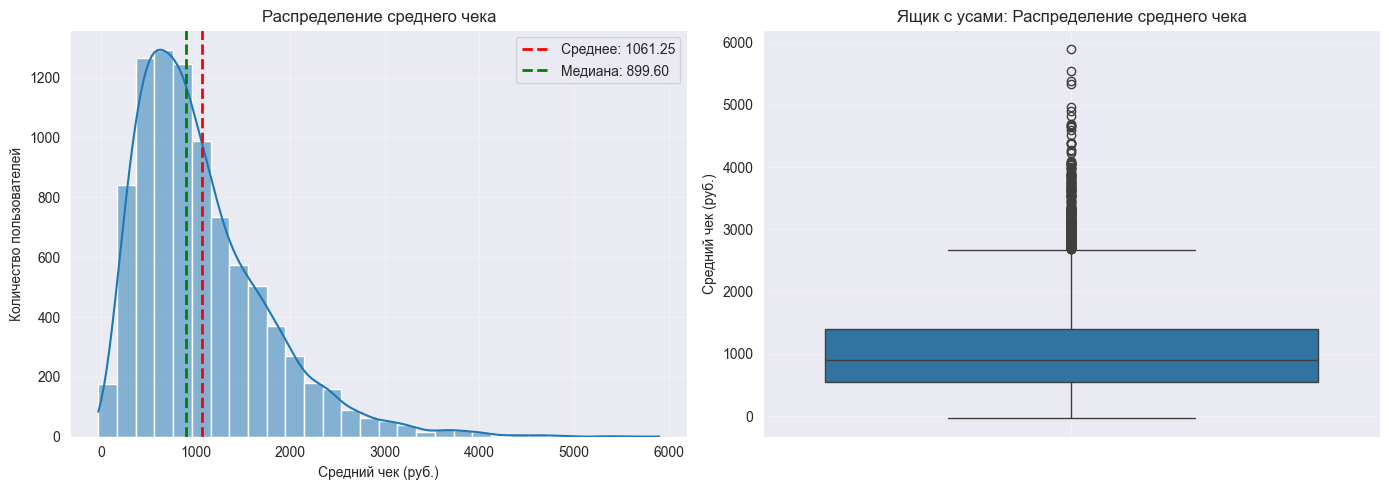

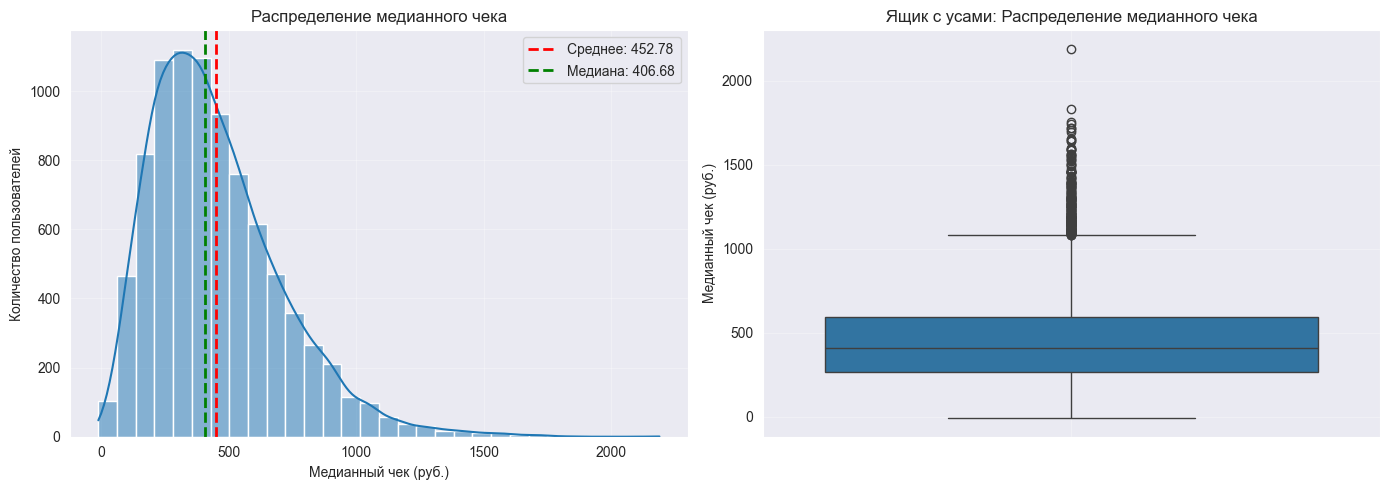

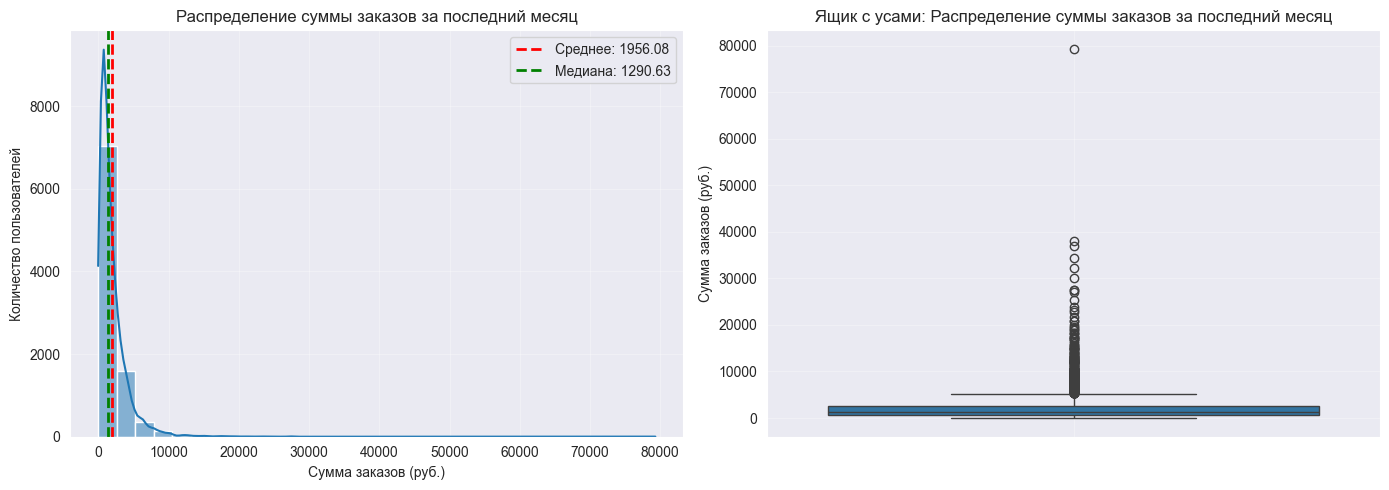

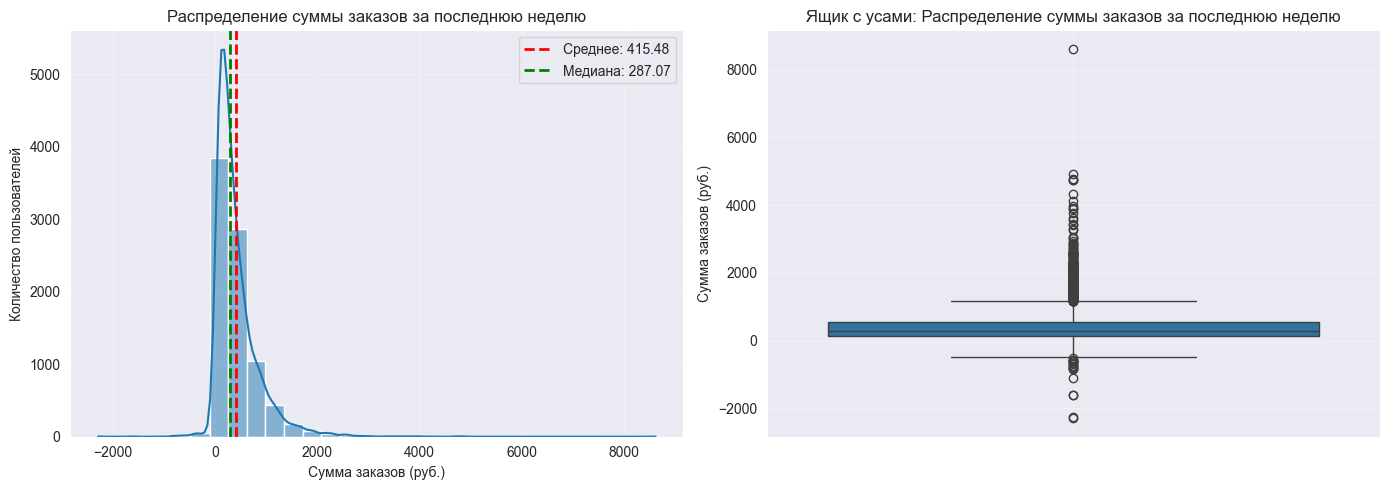

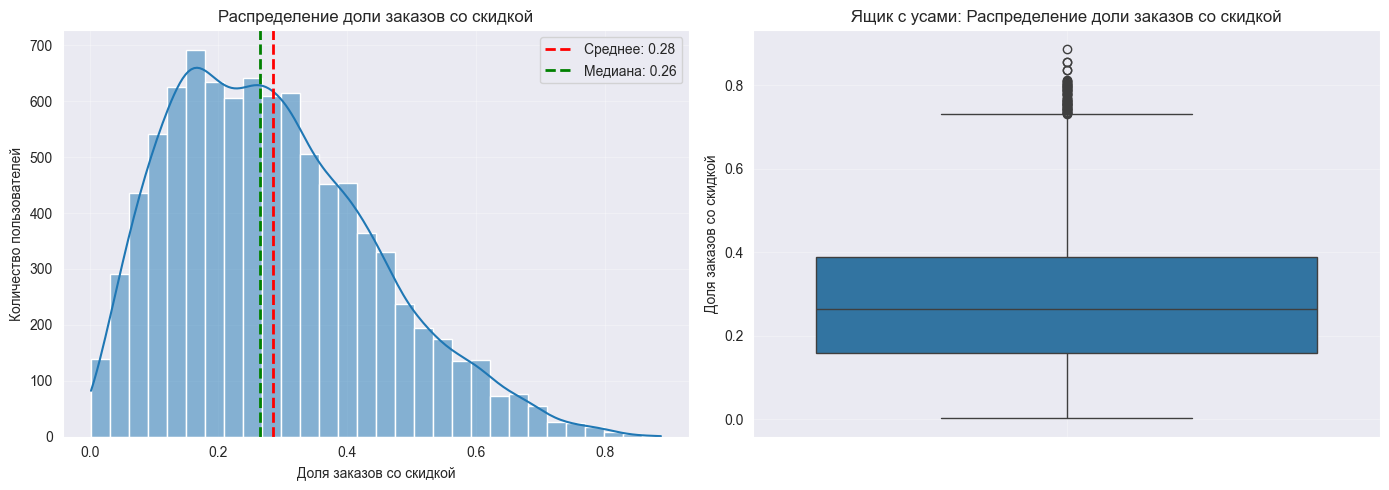

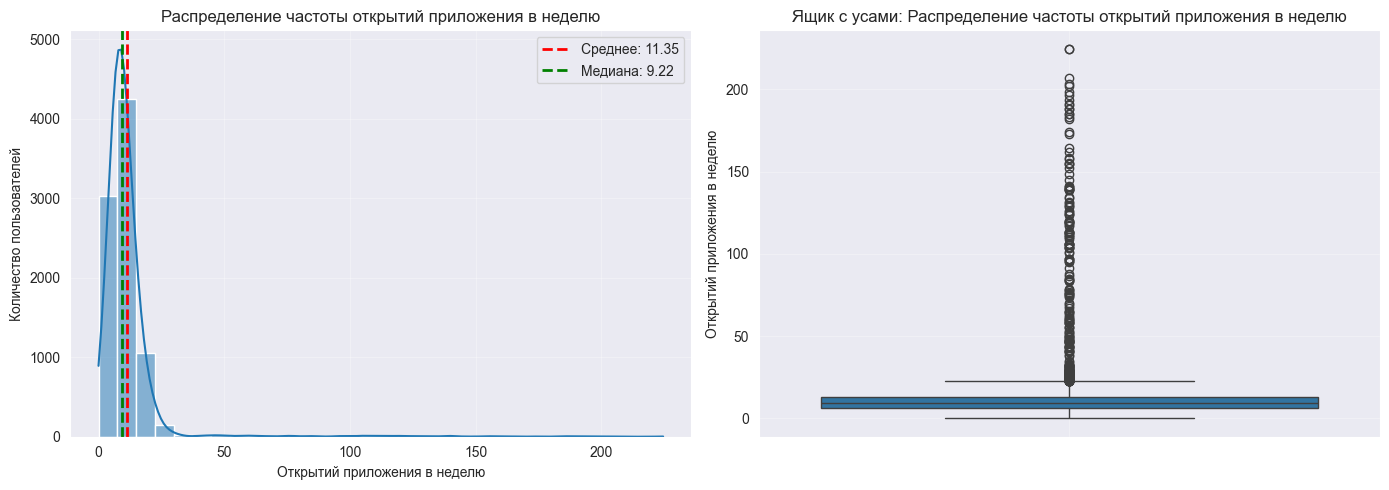

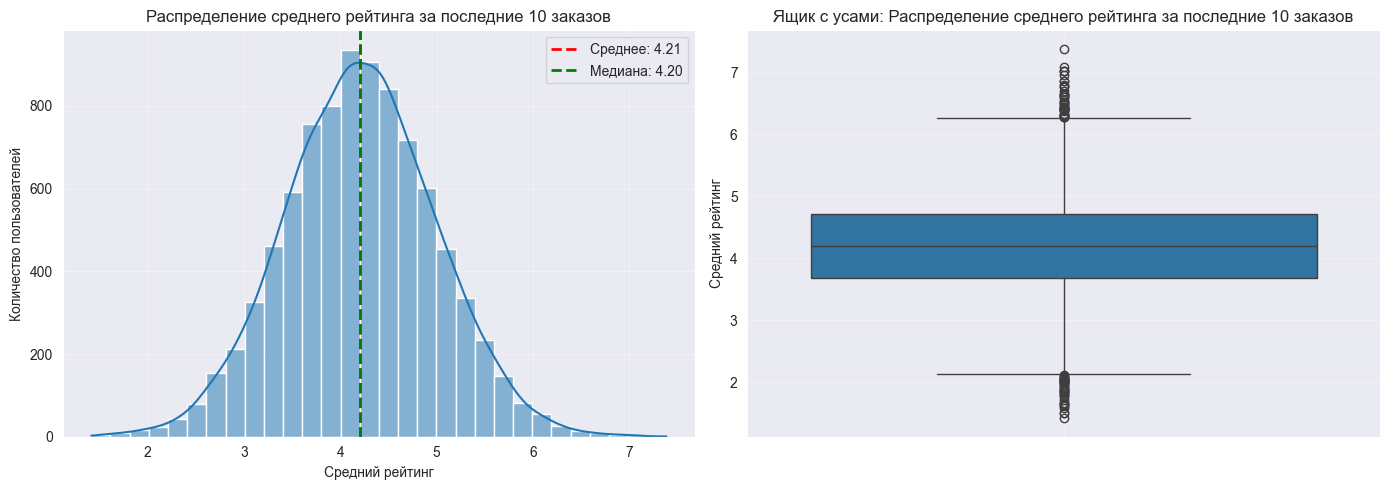

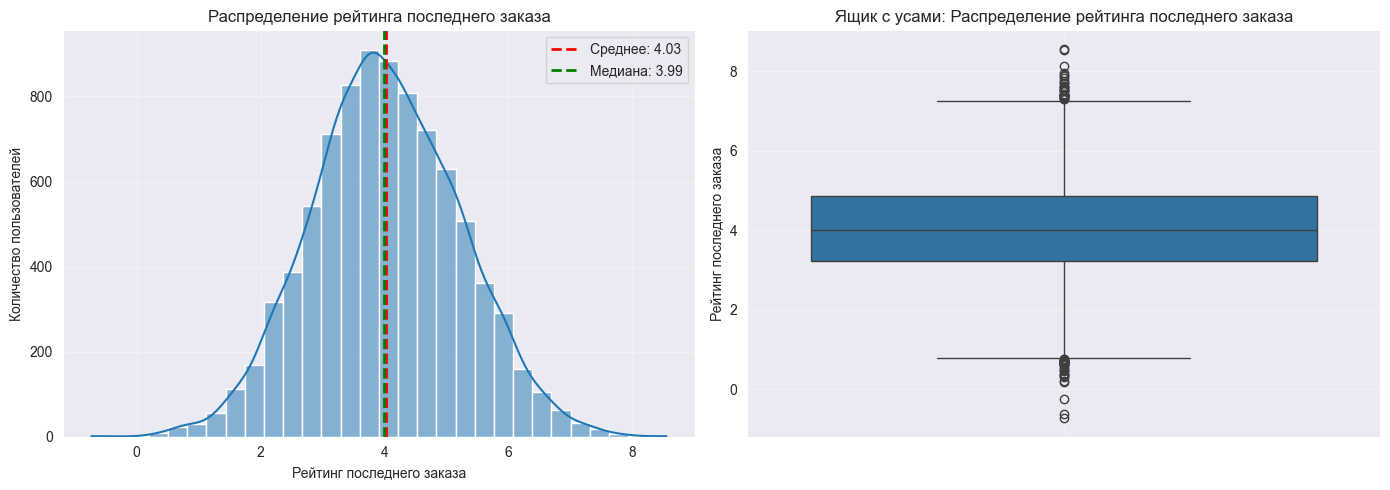

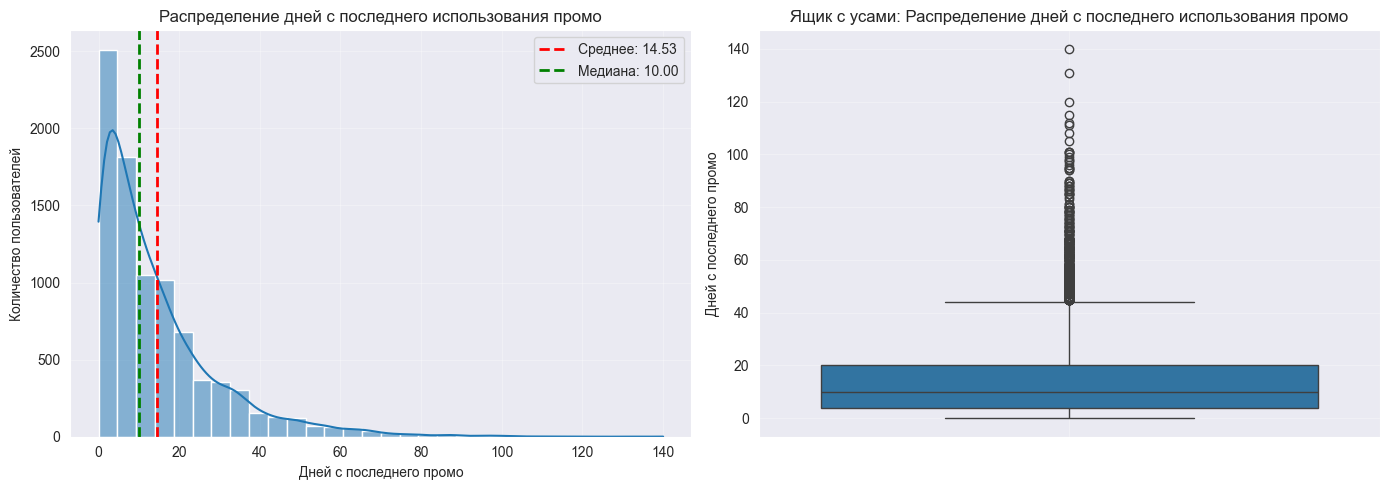

In [19]:
#Гистограммы и boxplot для непрерывных
for column in continuous_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    data = df[column].dropna()
    mean_val = data.mean()
    median_val = data.median()
    
    # Гистограмма
    sns.histplot(data, kde=True, bins=30, ax=ax1)
    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                label=f'Среднее: {mean_val:.2f}')
    ax1.axvline(median_val, color='green', linestyle='--', linewidth=2, 
                label=f'Медиана: {median_val:.2f}')
    
    # Подписи из словаря
    labels = plot_labels.get(column, {})
    ax1.set_title(labels.get('title', f'Гистограмма: {column}'))
    ax1.set_xlabel(labels.get('xlabel', column))
    ax1.set_ylabel(labels.get('ylabel', 'Количество наблюдений'))
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Boxplot
    sns.boxplot(y=data, ax=ax2)
    ax2.set_title(f'Ящик с усами: {labels.get("title", column)}')
    ax2.set_ylabel(labels.get('xlabel', column))
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

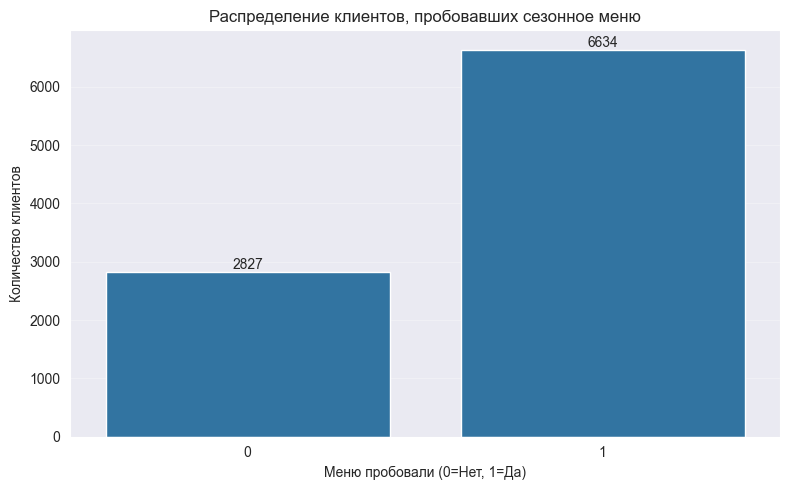

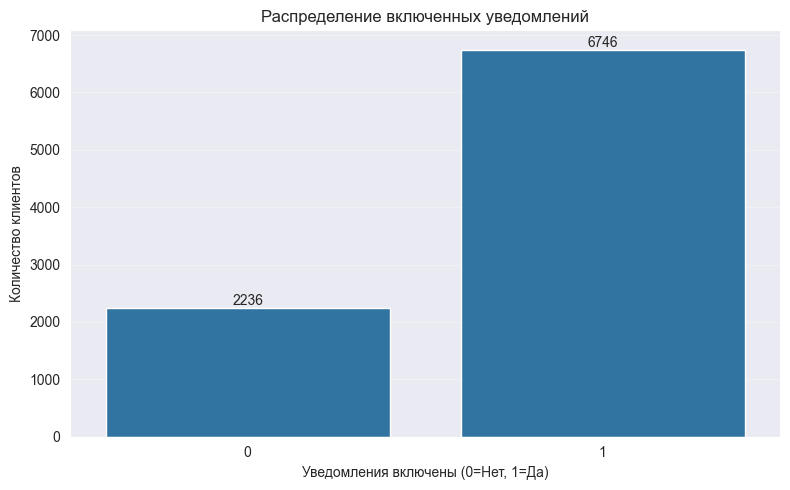

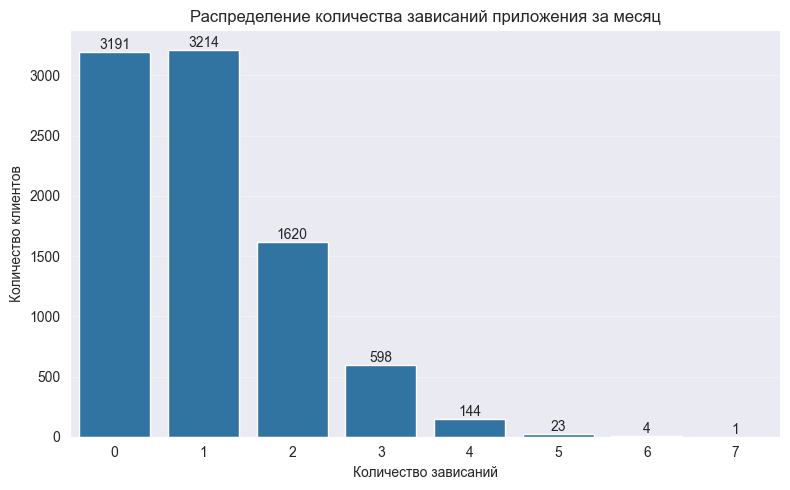

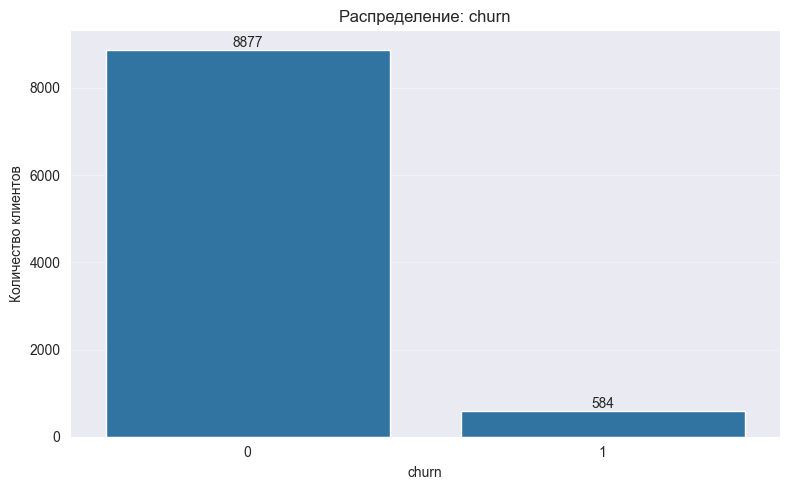

In [20]:
#Countplot для непрерывных
for column in discrete_cols:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    data = df[column].dropna().astype(int)
    labels = plot_labels.get(column, {})
    
    sns.countplot(x=data, ax=ax)
    ax.set_title(labels.get('title', f'Распределение: {column}'))
    ax.set_xlabel(labels.get('xlabel', column))
    ax.set_ylabel('Количество клиентов')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Добавим значения над столбцами
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

Во всех числовых колонках наблюдаются выбросы. Они нормальны везде, кроме столбца "total_spent_last_month". Там значения достигают 80000, когда основные данные находятся ниже 5 тысяч. Такие выбросы могут заставить модель смещаться в их сторону, поэтому от них нужно будет избавиться, отфильтровав значения по 99-му персентилю после разделения на выборки. Также отфильтровать по 99-му персентилю нужно будет "app_opens_per_week", так как в данных есть аномальное количество выбросов. В столбцах "order_frequency_week", "avg_order_value", "median_order_value", "total_spent_last_month", "total_spent_last_week", "review_rating_last_1" нужно убрать значения меньше нуля. Скорее всего это ошибка в данных, потому что эти признаки не могут принимать такие значения.

In [21]:
cols_to_check = ['order_frequency_week', 'avg_order_value',
                 'median_order_value', 'total_spent_last_month', 
                 'total_spent_last_week', 'review_rating_last_1']

# 1. количество строк с хотя бы одним отрицательным значением
has_negative = (df[cols_to_check] < 0).any(axis=1)
rows_with_negatives = has_negative.sum()

print(f"Дианостика:")
print(f"Всего строк в датасете: {len(df)}")
print(f"Строк с хотя бы одним отрицательным значением: {rows_with_negatives}")
print(f"Доля строк с отрицательными: {rows_with_negatives/len(df):.2%}")

Дианостика:
Всего строк в датасете: 9461
Строк с хотя бы одним отрицательным значением: 164
Доля строк с отрицательными: 1.73%


In [22]:
old_df = len(df)

cols_to_check = ['order_frequency_week', 'avg_order_value', 
                 'median_order_value', 'total_spent_last_month', 
                 'total_spent_last_week', 'review_rating_last_1']

df = df[~(df[cols_to_check] < 0).any(axis=1)]

new_df = len(df)
df_difference = old_df - new_df

print(f'Количество удаленных строк: {df_difference}')
print(f'Доля удаленных строк: {df_difference/old_df}')

Количество удаленных строк: 164
Доля удаленных строк: 0.01733431983934045


**2.9 Корреляция признаков и целевой переменной**

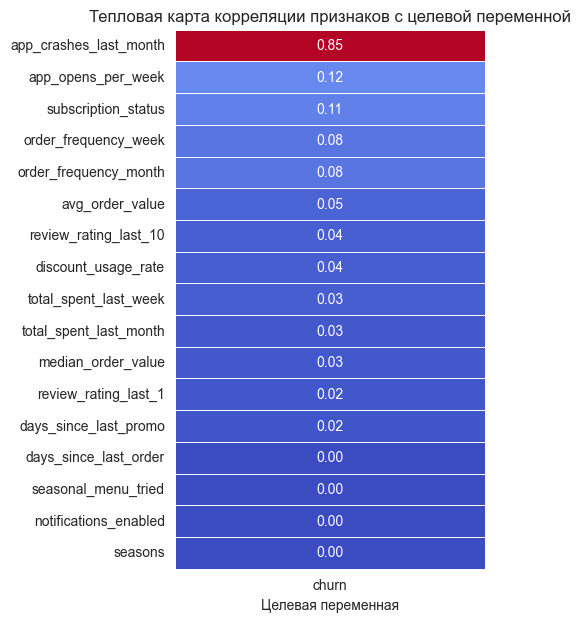

In [23]:
#Строим тепловую карту
interval_cols = ['days_since_last_order', 'order_frequency_month',
                 'order_frequency_week', 'avg_order_value','median_order_value', 
                 'total_spent_last_month','total_spent_last_week', 'discount_usage_rate',
                'app_opens_per_week', 'review_rating_last_10', 'review_rating_last_1',
                'days_since_last_promo']

correlation_matrix = df[['days_since_last_order','order_frequency_month',
                        'order_frequency_week', 'avg_order_value',
                        'median_order_value', 'total_spent_last_month',
                        'total_spent_last_week', 'discount_usage_rate',
                        'seasonal_menu_tried', 'subscription_status',
                        'app_opens_per_week', 'notifications_enabled',
                        'review_rating_last_10', 'review_rating_last_1',
                        'app_crashes_last_month', 'seasons',
                        'days_since_last_promo', 'churn']].phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(4,7))

data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'churn'][['churn']].sort_values(by='churn', ascending=False)

sns.heatmap(data_heatmap, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar=False)

plt.title('Тепловая карта корреляции признаков с целевой переменной')
plt.xlabel('Целевая переменная')
plt.show()

In [24]:
print(f'Корреляции с целевой переменной')
print(data_heatmap)

Корреляции с целевой переменной
                           churn
app_crashes_last_month  0.854092
app_opens_per_week      0.123241
subscription_status     0.105293
order_frequency_week    0.081644
order_frequency_month   0.080084
avg_order_value         0.046843
review_rating_last_10   0.039168
discount_usage_rate     0.035565
total_spent_last_week   0.034590
total_spent_last_month  0.026257
median_order_value      0.025478
review_rating_last_1    0.020251
days_since_last_promo   0.017295
days_since_last_order   0.000000
seasonal_menu_tried     0.000000
notifications_enabled   0.000000
seasons                 0.000000


Самая большая связь у целевой переменной наблюдается с признаком "app_crashes_last_month"(0.85). У четырех признаков не нашлась связь с переменной, но стоит брать во внимание, что пока что в данных присутствует большое количество пропусков, мешающих выявить взаимосвязь, поэтому пока не будем удалять эти признаки и используем их для обучения модели. Однако, в данных есть признаки, способные вызвать мультиколлинеарность. Очень похожи между собой "order_frequency_week" и "order_frequency_month", "total_spent_last_month" и "total_spent_last_week". В таких данных удалим столбцы, имеющие данные за неделю, так как месячные данные будут более информативными. Столбцы "avg_order_value" и "median_order_value" тоже очень похожи, поэтому оставим лишь медианные значения, так как они более стабильны. Столбцы "review_rating_last_1" и "review_rating_last_10" тоже мультиколлинеарны, поэтому оставим информацию о последних 10 заказах, так как последний заказ может быть лишь случайностью, а 10 заказов формируют паттерн.

In [25]:
#Удаляем мультиколлинеарные столбцы
columns_to_drop = ['order_frequency_week', 'total_spent_last_week', 'avg_order_value', 'review_rating_last_1']

df = df.drop(columns=columns_to_drop)

**2.10 Масштабирование**

В данных присутствуют разные масштабы данных. Выручка может измеряться в тысячах, а количество поломок приложения - в единицах. Для решения этой проблемы проведем стандартизацию после деления на выборки.

**2.11 Выводы после исследовательского анализа данных**

После проведения анализа данных было выявлено, что целевая переменная представлена в датасете несбалансированно. Почти все признаки модели имеют пропуски, которые в дальнейшем надо будет обработать. Также во время анализа были удалены столбцы 'user_id', 'preferred_roast', 'milk_preference', 'coffee_preference_change', 'last_coffee_type', 'last_drink_size', 'phone_type', 'coffee_bean_origin', 'geo_location' из-за отсутствия взаимосвязи между ними и переменной. Также во время анализа признаки, которые не должны содержать отрицательных значений, были отфильтрованы. Также была построена тепловая карта для выявления взаимосвязи. Больше всего связь находится с признаком "app_crashes_last_month"(0.85). В данных также есть нулевая связь, но ее не стоит оценивать до обработки пропусков. Также были найдены и удалены мультиколлинеарные признаки.

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



In [26]:
#Определим переменные
X = df.drop(columns=['churn'])
y = df['churn']

#Делим на выборки
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, 
                                                            stratify=y, shuffle=True,
                                                           random_state=RANDOM_STATE)

In [27]:
#Посмотрим распределение данных
print(f'Размерность обучающей выборки:{X_train_val.shape}')
print(f'Размерность тестовой выборки:{X_test.shape}')

Размерность обучающей выборки:(7437, 13)
Размерность тестовой выборки:(1860, 13)


In [28]:
#Сделаем функцию для фильтрации по 99 персентилю
def percentile_clip(X):
    X_np = np.asarray(X)
    X_clipped = X_np.copy()
    for i in range(X_clipped.shape[1]):
        p99 = np.percentile(X_clipped[:, i], 99)
        X_clipped[:, i] = np.where(X_clipped[:, i] > p99, p99, X_clipped[:, i])
    return X_clipped

In [29]:
#Категориальные признаки
cat_values = ['subscription_status', 'seasons']
#Числовые признаки
num_values = ['days_since_last_order', 'order_frequency_month', 'median_order_value',
             'discount_usage_rate', 'review_rating_last_10', 'app_crashes_last_month', 
              'days_since_last_promo']
#Значения для фильтрации
num_values_to_filter = ['total_spent_last_month', 'app_opens_per_week']
#Бинарные признаки
binary_values = ['seasonal_menu_tried', 'notifications_enabled']

clip_transformer = FunctionTransformer(
    percentile_clip, 
    feature_names_out='one-to-one'
)

preprocessor = ColumnTransformer([
    ('filter', Pipeline([
        ('clip', clip_transformer), 
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())]), num_values_to_filter),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_values),
    ('cat_one_hot', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
    ]), cat_values),
    ('binary', SimpleImputer(strategy='most_frequent'), binary_values)
])

In [30]:
dummy = DummyClassifier(strategy='most_frequent')

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25,
                                                 stratify=y_train_val, random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_val)

pr_auc = average_precision_score(y_val, y_pred)
print(f'PR-AUC у модели Dummy:{pr_auc:.4f}')

PR-AUC у модели Dummy:0.0618


Модель Dummy дает показатель PR-AUC = 0.0618, что будет отправной точкой для нашей основной модели, которая не должна показывать метрики ниже этой.

In [31]:
base_pipeline = Pipeline([
    ('processor', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

N_FOLDS = 5

kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = ['average_precision', 'neg_log_loss', 'roc_auc']

base_cv = cross_validate(base_pipeline, X_train_val, y_train_val, 
                         scoring=scoring, cv=kfold, return_train_score=False, n_jobs=-1, error_score='raise')

base_means = {
    'PR-AUC':base_cv['test_average_precision'].mean(),
    'Log_loss': -base_cv['test_neg_log_loss'].mean(),
    'ROC-AUC': base_cv['test_roc_auc'].mean()
}
print(f'Результаты базовой модели:')
print(f"PR_AUC: {base_means['PR-AUC']:.3f}")
print(f"Log loss: {base_means['Log_loss']:.3f}")
print(f"ROC_AUC: {base_means['ROC-AUC']:.3f}")

Результаты базовой модели:
PR_AUC: 0.681
Log loss: 0.123
ROC_AUC: 0.925


В данных представлены 6% положительных примеров, значит случайная модель будет давать PR-AUC 0.06. Базовая модель работает в 10 раз лучше случайной. Это значит, что она пригодна для использования, но есть место для улучшения. Все метрики показывают относительно хорошие значения.

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

In [32]:
#Создадим функцию для преображения признаков
def create_enhanced_features(X):
    """
    Создание расширенного списка признаков
    """
    X_enhanced = X.copy()
    
    #Логарифмируем total_spent_last_month
    X_enhanced['total_spent_sqrt'] = np.log1p(X['total_spent_last_month'])
    
    #Возведем в квардрат app_crashes_last_month
    X_enhanced['app_crashes_square'] = X['app_crashes_last_month'] ** 2
    
    #Разделим total_spent_last_month на app_crashes_last_month
    X_enhanced['spent_crashes'] = X['total_spent_last_month']/(X['app_crashes_last_month']+1)
    
    #Удаляем использваонные столбцы
    columns_to_drop = ['total_spent_last_month', 'app_crashes_last_month']
    X_enhanced = X_enhanced.drop(columns=columns_to_drop)
    
    return X_enhanced

In [33]:
#Применяем функцию на данных
X_train_val_enhanced = create_enhanced_features(X_train_val)

In [34]:
#Создаем новый pipeline
#Категориальные признаки
cat_values_enhanced = ['subscription_status', 'seasons']
#Числовые признаки
num_values_enhanced = ['days_since_last_order', 'median_order_value', 
              'review_rating_last_10', 'days_since_last_promo',
             'total_spent_sqrt', 'app_crashes_square',
             'spent_crashes', 'discount_usage_rate', 'order_frequency_month']
#Значения для фильтрации
num_values_to_filter_enhanced = ['app_opens_per_week']
#Бинарные признаки
binary_values_enhanced = ['seasonal_menu_tried', 'notifications_enabled']

enhanced_preprocessor = ColumnTransformer([
    ('filter', Pipeline([
        ('clip', clip_transformer), 
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())]), num_values_to_filter_enhanced),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_values_enhanced),
    ('cat_one_hot', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
    ]), cat_values_enhanced),
    ('binary', SimpleImputer(strategy='most_frequent'), binary_values_enhanced)
])

In [35]:
enhanced_pipeline = Pipeline([
    ('processor', enhanced_preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

enhanced_cv = cross_validate(enhanced_pipeline, X_train_val_enhanced, y_train_val, 
                         scoring=scoring, cv=kfold, return_train_score=False, n_jobs=-1, error_score='raise')

enhanced_means = {
    'PR-AUC':enhanced_cv['test_average_precision'].mean(),
    'Log_loss': -enhanced_cv['test_neg_log_loss'].mean(),
    'ROC-AUC': enhanced_cv['test_roc_auc'].mean()
}
print(f'Результаты улучшенной модели:')
print(f"PR_AUC: {enhanced_means['PR-AUC']:.3f}")
print(f"Log loss: {enhanced_means['Log_loss']:.3f}")
print(f"ROC_AUC: {enhanced_means['ROC-AUC']:.3f}")

Результаты улучшенной модели:
PR_AUC: 0.687
Log loss: 0.118
ROC_AUC: 0.930


После добавления новых признаков модель показала немного лучше показатели на метриках. PR-AUC выросла на 0.006, log loss упала на 0.005, а ROC-AUC выросла на 0.005. Изменения небольшие, но всё же показывают лучшую стабильность.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

In [36]:
#Перечисление гипепараметров
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

results = []

for c in C_values:
    model_pipeline = Pipeline([('processor', enhanced_preprocessor),
                               ('model', LogisticRegression(C=c, random_state=RANDOM_STATE))])
    scoring_model = ['average_precision']
    model_cv = cross_validate(model_pipeline, X_train_val_enhanced, y_train_val, 
                                 scoring=scoring_model, cv=kfold, return_train_score=False, 
                                 n_jobs=-1, error_score='raise')
    model_means = {'PR-AUC':model_cv['test_average_precision'].mean()}
    results.append((c, model_means['PR-AUC']))
    
print(f'Сравнение гиперпараметров:')
for c, pr_auc in results:
    print(f'C = {c}: PR-AUC = {pr_auc:.5f}')
    
# Находим лучшее значение C
best_c, best_score = max(results, key=lambda x: x[1])
print(f"\nЛучшее значение C: {best_c} с PR-AUC = {best_score:.5f}")

Сравнение гиперпараметров:
C = 0.001: PR-AUC = 0.68557
C = 0.01: PR-AUC = 0.68796
C = 0.1: PR-AUC = 0.68944
C = 1: PR-AUC = 0.68732
C = 10: PR-AUC = 0.68703
C = 100: PR-AUC = 0.68702
C = 1000: PR-AUC = 0.68702

Лучшее значение C: 0.1 с PR-AUC = 0.68944


После перебора гиперпараметров на улучшенных признаках было выявлено, что модель лучше всего предсказывает со значением C=0.1. Далее обучим модель на всех данных, используя улучшенные признаки и гиперпараметр = 0.1.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [37]:
#Обучаем модель на всех данных
final_pipeline = Pipeline([('processor', enhanced_preprocessor),
                           ('model', LogisticRegression(C=0.1, random_state=RANDOM_STATE))])
final_pipeline.fit(X_train_val_enhanced, y_train_val)
X_test_final = create_enhanced_features(X_test)

y_test_pred_proba = final_pipeline.predict_proba(X_test_final)[:, 1]
y_test_pred = final_pipeline.predict(X_test_final)

final_pr_auc = average_precision_score(y_test, y_test_pred_proba)
final_log_loss = log_loss(y_test, y_test_pred_proba)
final_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("Финальные результаты на тестовой выборке:")
print(f"PR-AUC:   {final_pr_auc:.3f}")
print(f"Log Loss: {final_log_loss:.3f}")
print(f"ROC-AUC:   {final_roc_auc:.3f}")

Финальные результаты на тестовой выборке:
PR-AUC:   0.707
Log Loss: 0.116
ROC-AUC:   0.923


После обучения модели на всех данных и проведения финальной оценки на тестовой выборке можно сказать, что модель улучшила свои показатели. PR-AUC выросла на 0,018, что является очень хорошим знаком. Модель показывает примерно одинаковые значения на обучающей и тестовой выборке, что говорит об отсутствии переобучения. На тестовых данных модель показывает PR-AUC почти в 12 раз выше случайной модели.

In [38]:
#Выведим итоговые коэффициенты модели
preprocessor = final_pipeline.named_steps['processor']
feature_names = preprocessor.get_feature_names_out()
model = final_pipeline.named_steps['model']
coefficients = model.coef_[0]

coef_pairs = list(zip(feature_names, coefficients))

# Сортируем по значению коэффициента
coef_pairs.sort(key=lambda x: x[1], reverse=True)

print("\nКоэффициенты:")
for name, coef in coef_pairs:
    print(f"{name}: {coef:.4f}")


Коэффициенты:
num__app_crashes_square: 1.6319
cat_one_hot__subscription_status_pro: 0.8879
num__order_frequency_month: 0.5320
cat_one_hot__subscription_status_premium: 0.4126
cat_one_hot__seasons_unknown: 0.3320
filter__app_opens_per_week: 0.1792
num__total_spent_sqrt: 0.1152
num__days_since_last_promo: 0.1037
num__days_since_last_order: 0.0706
num__median_order_value: 0.0214
num__discount_usage_rate: 0.0144
cat_one_hot__subscription_status_unknown: -0.0834
cat_one_hot__seasons_winter: -0.1290
cat_one_hot__seasons_summer: -0.1344
cat_one_hot__subscription_status_none: -0.1381
binary__notifications_enabled: -0.1749
num__review_rating_last_10: -0.1779
cat_one_hot__seasons_spring: -0.2209
binary__seasonal_menu_tried: -0.2427
num__spent_crashes: -0.2827


## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

Итоговая модель показала хорошие результаты на обучающей и тестовой выборках. На тестовой выборке метрика PR-AUC = 0.707, что почти в 12 раз выше работы случайной модели. Результаты высокие, а значит модель можно рекомендовать к использованию.
Главным признаком модель выявила количество зависаний приложения в этом месяце. Связь прямая, а значит чем больше зависаний, тем больше уходит клиентов. Для бизнеса это важные результаты, ведь наладив работу приложения можно остановить отток клиентов. 
Максимальная обратная связь наблюдается с отсутствием подписки. Возможно, всё зависит от того, что уходящие пользователи заранее менее заинтересованы, чтобы оформлять подписку.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [39]:
#Сохраняем модель и метаданные
date = datetime.now().strftime("%Y%m%d")
version = "1.0"
model_name = f"churn_detection_v{version}_{date}.pkl"

metadata = {
    'model_version': '1.0',
    'training_date': '01.04.2026',
    'accuracy': '0.734',
    'features':['app_opens_per_week', 'days_since_last_order', 'median_order_value', 
              'review_rating_last_10', 'days_since_last_promo',
             'total_spent_sqrt', 'app_crashes_square',
             'spent_crashes', 'discount_usage_rate', 'order_frequency_month',
               'subscription_status', 'seasons', 'seasonal_menu_tried', 'notifications_enabled']
}
joblib.dump({
    'model':final_pipeline,
    'metadata': metadata
}, model_name)

['churn_detection_v1.0_20260410.pkl']

In [40]:
#Проверяем сохраненную модель
loaded_data = joblib.load(model_name)
loaded_pipeline = loaded_data['model']

y_checked_pred_proba = loaded_pipeline.predict_proba(X_test_final)[:, 1]
y_checked_pred = loaded_pipeline.predict(X_test_final)

checked_pr_auc = average_precision_score(y_test, y_checked_pred_proba)
checked_log_loss = log_loss(y_test, y_checked_pred_proba)
checked_roc_auc = roc_auc_score(y_test, y_checked_pred_proba)

print("Результаты проверки на тестовой выборке:")
print(f"PR-AUC:   {checked_pr_auc:.3f}")
print(f"Log Loss: {checked_log_loss:.3f}")
print(f"ROC-AUC:   {checked_roc_auc:.3f}")

Результаты проверки на тестовой выборке:
PR-AUC:   0.707
Log Loss: 0.116
ROC-AUC:   0.923


Модель успешно сохранена!